In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile as zf

In [ ]:
zip_file_path = r'/content/drive/MyDrive/Python Bootcamp Uplift/archive.zip'
extracted_file_path = r'/content/drive/MyDrive/Python Bootcamp Uplift/'

In [ ]:
with zf.ZipFile(zip_file_path) as reference:
  reference.extractall(extracted_file_path)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = r'/content/drive/MyDrive/Python Bootcamp Uplift/Family Income and Expenditure.csv'

In [ ]:
df = pd.read_csv(file_path)

In [ ]:
df.shape

(41544, 60)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41544 entries, 0 to 41543
Data columns (total 60 columns):
 #   Column                                         Non-Null Count  Dtype 
---  ------                                         --------------  ----- 
 0   Total Household Income                         41544 non-null  int64 
 1   Region                                         41544 non-null  object
 2   Total Food Expenditure                         41544 non-null  int64 
 3   Main Source of Income                          41544 non-null  object
 4   Agricultural Household indicator               41544 non-null  int64 
 5   Bread and Cereals Expenditure                  41544 non-null  int64 
 6   Total Rice Expenditure                         41544 non-null  int64 
 7   Meat Expenditure                               41544 non-null  int64 
 8   Total Fish and  marine products Expenditure    41544 non-null  int64 
 9   Fruit Expenditure                              41544 non-null

In [ ]:
# Activity 2: Uncovering Stories From Data Next Week (Jeth, Brandon, Richard, Kev, AJ)

  # WE CHOSE ONLY TOP (3) RURAL AND URBRAN REGIONS FOR THIS EXERCISE

  # 1. Look at Different Regions (2 or more) then compare the household income from one to another  - AJ
  # 2. Highest Educational attainment on the head of the household, then correlation on the income of household, (Just Select 5 categories) - RICHARD
  # 3. Household size and spending correlation; fam of 5 vs fam of 15 - KIEV
  # 4. Household Economics based on Gender... expense on alcoholic if male head? - JETH
  # 5. Regional Spending Patterns, could look at different category (like 5 or more) - BRANDON
  # 6. Personal Exploration // find (3) insightful formation

          # Medical Expenditure by Gender of Household Head - AJ
          # Medical Expenditure by Urban/Rural Classification - AJ
          # Household Differences by Gender of Household Head
          # Average Alcohol & Tobacco Expenditure by Household Head Sex
          # Family Member size and Food/Education Expenditure

In [ ]:
# 1. Look at Different Regions (2 or more) then compare the household income from one to another

# FILTER FOR TOP 3 URBAN AND RURAL

urban_regions = ['NCR', 'IVA - CALABARZON', 'VII - Central Visayas']
rural_regions = ['II - Cagayan Valley', 'V - Bicol Region', 'VIII - Eastern Visayas']

df_urban = df[df['Region'].isin(urban_regions)]
df_rural = df[df['Region'].isin(rural_regions)]


# Below is my initial code, but i find that there's shorter way to do it (above)...

#regions_to_filter = ['NCR', 'IVA - CALABARZON', 'VII - Central Visayas']
#filt = df['Region'].isin(regions_to_filter)
#df_urban = df[filt]

#regions_to_filter = ['II - Cagayan Valley', 'V - Bicol Region', 'VIII - Eastern Visayas']
#filt = df['Region'].isin(regions_to_filter)
#df_rural = df[filt]

In [ ]:
# Filter for my combined Rural regions /  Urban regions instead of lamda...

urban_regions = ['NCR', 'IVA - CALABARZON', 'VII - Central Visayas']
rural_regions = ['II - Cagayan Valley', 'V - Bicol Region', 'VIII - Eastern Visayas']

all_regions = urban_regions + rural_regions

filtered_regions = df[df['Region'].isin(all_regions)].copy()

region_type = {
'NCR': 'Urban',
'IVA - CALABARZON': 'Urban',
'VII - Central Visayas': 'Urban',

'II - Cagayan Valley': 'Rural',
'V - Bicol Region': 'Rural',
'VIII - Eastern Visayas': 'Rural'
}

filtered_regions['Urban_Rural'] = filtered_regions['Region'].map(region_type)

# Calculate Total Expenditure for filtered_regions
filtered_regions['Total Expenditure'] = filtered_regions['Total Food Expenditure'] + filtered_regions['Alcoholic Beverages Expenditure'] + \
                          filtered_regions['Restaurant and hotels Expenditure'] + filtered_regions['Tobacco Expenditure'] + \
                          filtered_regions['Clothing, Footwear and Other Wear Expenditure'] + filtered_regions['Housing and water Expenditure'] + \
                          filtered_regions['Medical Care Expenditure'] + filtered_regions['Transportation Expenditure'] + filtered_regions['Communication Expenditure'] + \
                          filtered_regions['Education Expenditure'] + filtered_regions['Miscellaneous Goods and Services Expenditure'] + filtered_regions['Special Occasions Expenditure'] + \
                          filtered_regions['Crop Farming and Gardening expenses'] + filtered_regions['Imputed House Rental Value']

# Calculate Monthly Expenditure for filtered_regions
filtered_regions['Monthly Expenditure'] = filtered_regions['Total Expenditure'] / 12

# Calculate Monthly Income for filtered_regions
filtered_regions['Monthly Income'] = filtered_regions['Total Household Income']/12

In [ ]:
# Total Expenditure from the discussion

df['Total Expenditure'] = df['Total Food Expenditure'] + df['Alcoholic Beverages Expenditure'] + \
                          df['Restaurant and hotels Expenditure'] + df['Tobacco Expenditure'] + \
                          df['Clothing, Footwear and Other Wear Expenditure'] + df['Housing and water Expenditure'] + \
                          df['Medical Care Expenditure'] + df['Transportation Expenditure'] + df['Communication Expenditure'] + \
                          df['Education Expenditure'] + df['Miscellaneous Goods and Services Expenditure'] + df['Special Occasions Expenditure'] + \
                          df['Crop Farming and Gardening expenses'] + df['Imputed House Rental Value']

In [ ]:
# to make the total expenditure into monthly

df['Monthly Expenditure'] = df['Total Expenditure'] / 12

In [ ]:
# to make total income into monthly

df['Monthly Income'] = df['Total Household Income']/12

THE FOLLOWING GRAPH ARE MODIFIED BASED ON SIR JC'S RECOMMENDATION DURING PRESENTATION

In [ ]:
# Reflecting the Monthly Income vs Monthly Expenditure

region_table = filtered_regions.groupby(['Urban_Rural', 'Region'])[['Monthly Income','Monthly Expenditure']].mean().round(2)
region_table

Monthly Income  Monthly Expenditure
Urban_Rural Region                                                     
Rural       II - Cagayan Valley           19731.52             17960.47
            V - Bicol Region              15508.79             15213.65
            VIII - Eastern Visayas        16394.72             14113.35
Urban       IVA - CALABARZON              25280.04             24319.98
            NCR                           35071.82             33709.61
            VII - Central Visayas         19575.78             18139.27

In [ ]:
# Including the percetage per Sir JC's recommendation

filtered_regions['% Income Spent'] = (filtered_regions['Monthly Expenditure']/filtered_regions['Monthly Income']) * 100

filtered_regions['% Income Saved'] = 100 - filtered_regions['% Income Spent']

In [ ]:
region_table = filtered_regions.groupby(['Urban_Rural', 'Region'])[['Monthly Income','Monthly Expenditure','% Income Spent','% Income Saved']].mean().round(2)
region_table

Monthly Income  Monthly Expenditure  \
Urban_Rural Region                                                        
Rural       II - Cagayan Valley           19731.52             17960.47   
            V - Bicol Region              15508.79             15213.65   
            VIII - Eastern Visayas        16394.72             14113.35   
Urban       IVA - CALABARZON              25280.04             24319.98   
            NCR                           35071.82             33709.61   
            VII - Central Visayas         19575.78             18139.27   

                                    % Income Spent  % Income Saved  
Urban_Rural Region                                                  
Rural       II - Cagayan Valley             101.53           -1.53  
            V - Bicol Region                109.32           -9.32  
            VIII - Eastern Visayas          101.17           -1.17  
Urban       IVA - CALABARZON                106.51           -6.51  
            NCR                             105.00           -5.00  
            VII - Central Visayas           112.85          -12.85

In [ ]:
# Insights

# The results show that several regions exhibit expenditure levels slightly exceeding their average monthly income, resulting in negative savings rates.
# This suggests that some households rely on borrowing, savings, or informal financial sources to meet their expenditures.
# Sir Jet is correct when he discussed that some household are overspending haha omg

In [ ]:
region_table_reset = region_table.reset_index()

region_melt = region_table_reset.melt(
    id_vars=['Urban_Rural','Region'],
    value_vars=['Monthly Income','Monthly Expenditure'],
    var_name='Category',
    value_name='Amount'
)

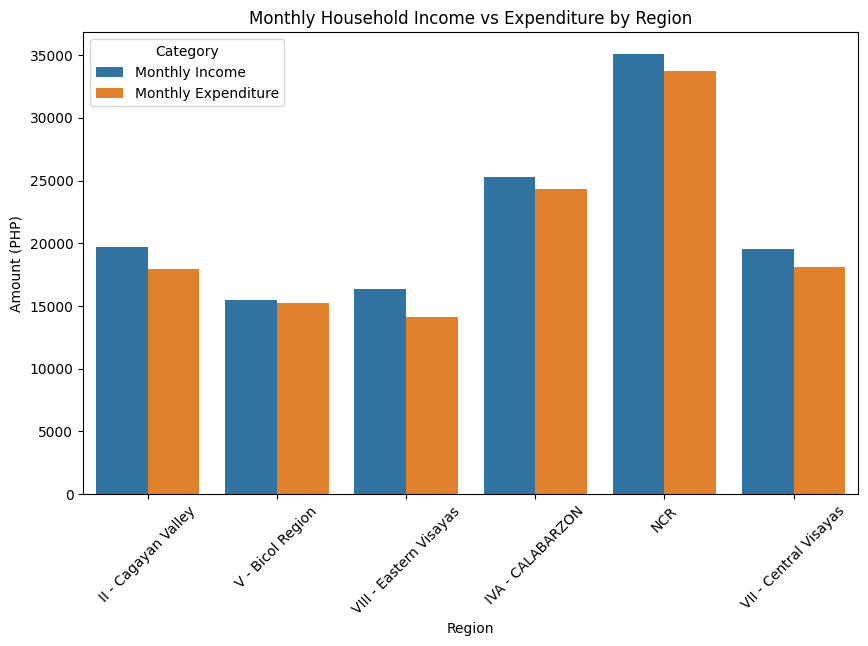

In [ ]:
# Monthly Income vs Monthly Expenditure by Region

plt.figure(figsize=(10,6))
sns.barplot(data=region_melt, x='Region', y='Amount', hue='Category')

plt.title('Monthly Household Income vs Expenditure by Region')
plt.xlabel('Region')
plt.ylabel('Amount (PHP)')
plt.xticks(rotation=45)

plt.show()

In [ ]:
# INSIGHTS

# Urban regions show higher household income.
# Expenditures closely follow income levels.
# NCR has the highest income and spending.
# Limited savings capacity across regions.
# Rural regions have lower income levels.

In [ ]:
region_table_reset = region_table.reset_index()

percent_melt = region_table_reset.melt(
    id_vars=['Urban_Rural','Region'],
    value_vars=['% Income Spent', '% Income Saved'],
    var_name='Category',
    value_name='Percentage'
)

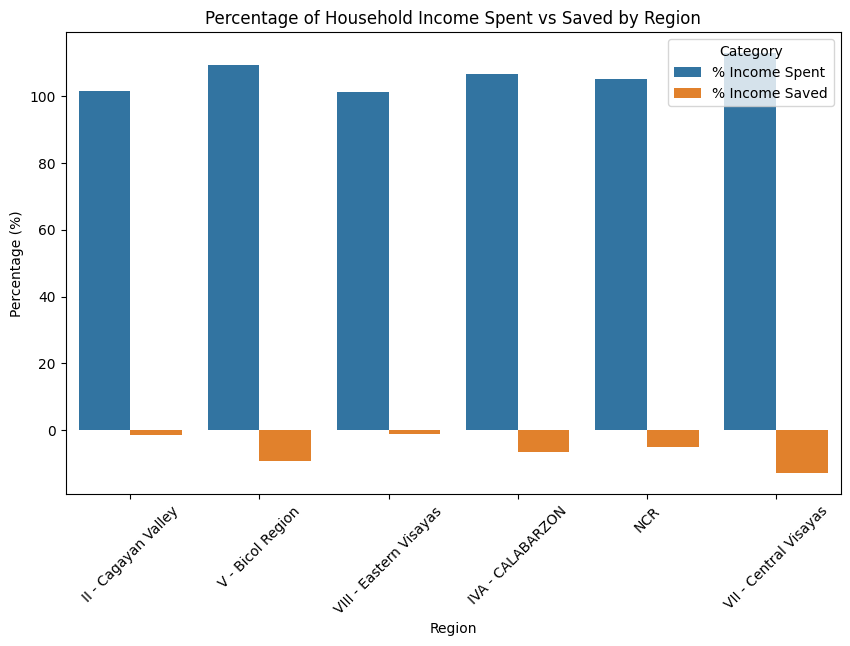

In [ ]:
# Percentage of Household Income Spent vs Saved by Region

plt.figure(figsize=(10,6))

sns.barplot(
    data=percent_melt,
    x='Region',
    y='Percentage',
    hue='Category'
)

plt.title('Percentage of Household Income Spent vs Saved by Region')
plt.ylabel('Percentage (%)')
plt.xlabel('Region')

plt.xticks(rotation=45)

plt.show()

In [ ]:
# INSIGHTS

# Households spend most of their income.
# Negative savings appear in several regions.
# Rural regions show higher financial pressure.
# Urban regions still have limited savings.
# Both regions experience limited savings capacity, with expenditures consuming nearly all household income.

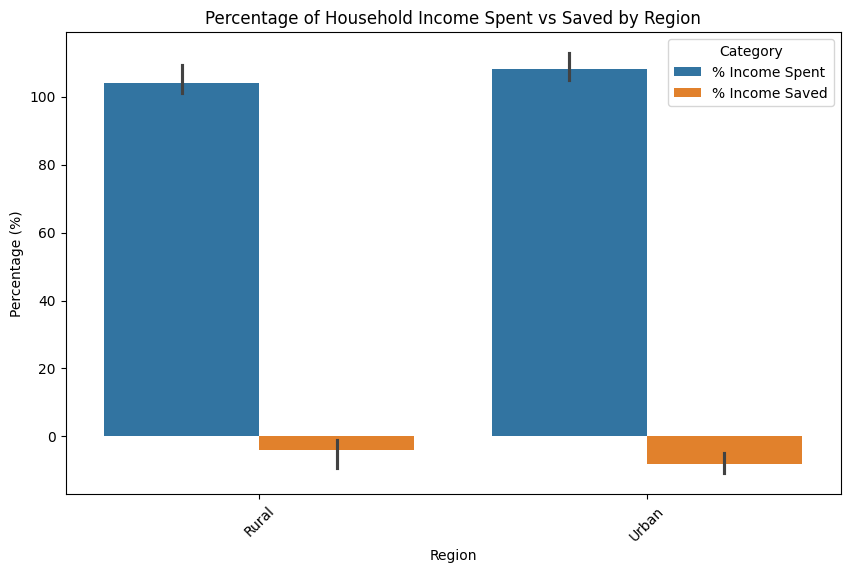

In [ ]:
# Rural vs Urban on Income Spent vs Income Saved

plt.figure(figsize=(10,6))

sns.barplot(
    data=percent_melt,
    x='Urban_Rural',
    y='Percentage',
    hue='Category'
)

plt.title('Percentage of Household Income Spent vs Saved by Region')
plt.ylabel('Percentage (%)')
plt.xlabel('Region')

plt.xticks(rotation=45)

plt.show()

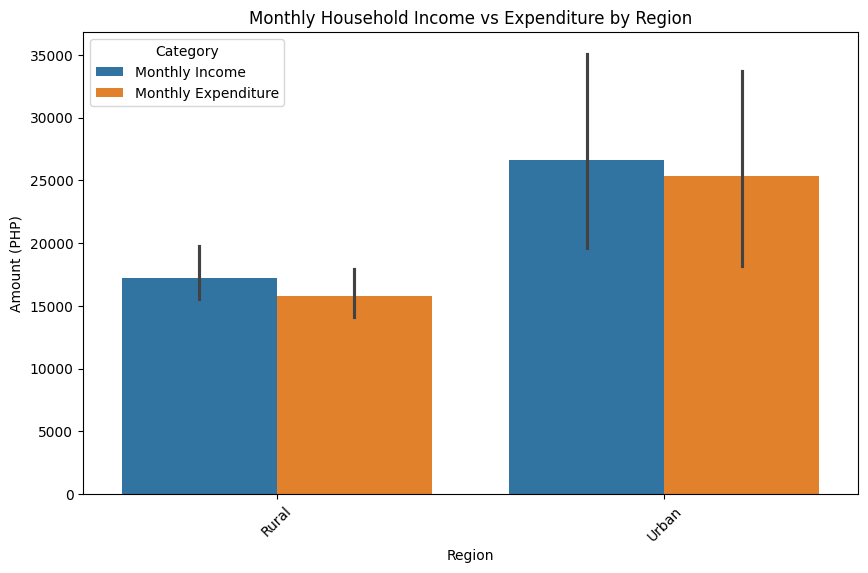

In [ ]:
# Rural vs Urban on Monthly Income vs Monthly Expenditure

plt.figure(figsize=(10,6))
sns.barplot(data=region_melt, x='Urban_Rural', y='Amount', hue='Category')

plt.title('Monthly Household Income vs Expenditure by Region')
plt.xlabel('Region')
plt.ylabel('Amount (PHP)')
plt.xticks(rotation=45)

plt.show()

# PERSONAL EXPLORATION
  MEDICAL EXPENDITURE BY GENDER; RURAL/URBAN CLASSIFICATION


In [ ]:
filtered_regions['Monthly Medex'] = filtered_regions['Medical Care Expenditure'] / 12

In [ ]:
medical_table_sex = filtered_regions.groupby('Household Head Sex')['Monthly Medex'].mean().round(2)
medical_table_sex

,Monthly Medex
Household Head Sex,
Female,854.44
Male,614.53


In [ ]:
medical_table_reg = filtered_regions.groupby('Urban_Rural')['Monthly Medex'].mean().round(2)
medical_table_reg

,Monthly Medex
Urban_Rural,
Rural,478.71
Urban,798.56


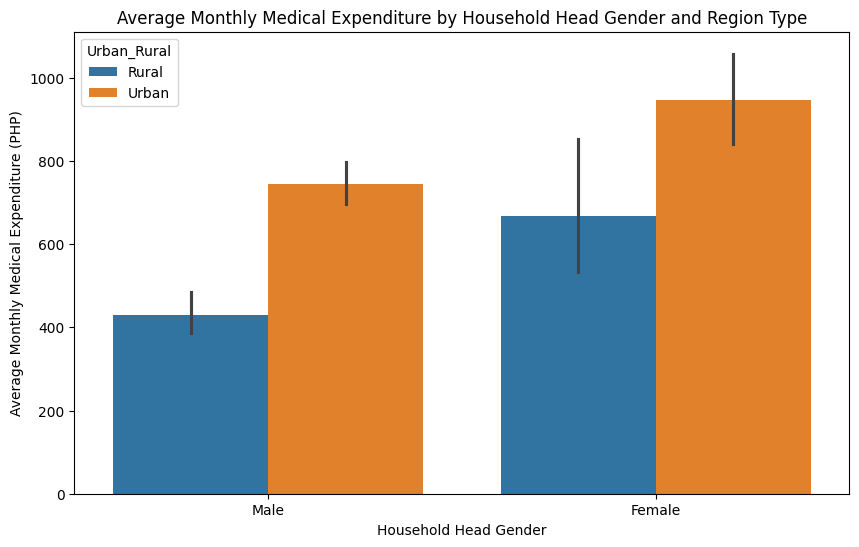

In [ ]:
# Average Monthly Medical Expenditure by Gender of Household Head and Region Type

plt.figure(figsize=(10,6))

sns.barplot(
    data=filtered_regions,
    x='Household Head Sex',
    y='Monthly Medex',
    hue='Urban_Rural',
)

plt.title('Average Monthly Medical Expenditure by Household Head Gender and Region Type')
plt.xlabel('Household Head Gender')
plt.ylabel('Average Monthly Medical Expenditure (PHP)')

plt.show()

In [ ]:
# INSIGHTS

# Across both urban and rural regions, households headed by females show higher average monthly medical expenditures compared to those headed by males.
# Medical expenditures are consistently higher in urban regions than in rural regions, likely due to higher healthcare costs and greater access to medical services in cities.
# Among the groups, female-headed households in urban areas record the highest average monthly medical expenditure.
# Among the groups, female-headed households in urban areas record the highest average monthly medical expenditure.
# The results suggest that both gender of the household head and regional classification influence household medical spending.